In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Dataset Analysis**

In [ ]:
df = pd.read_csv("../data/raw/ObesityDataSet_raw_and_data_sinthetic.csv")
df

In [ ]:
df['FCVC'] = df['FCVC'].round().astype(int)

In [26]:
df.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                                int64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

In [27]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


In [28]:
print("Numerical Features Summary:\n", df.describe())

Numerical Features Summary:
                Age       Height       Weight         FCVC          NCP  \
count  2111.000000  2111.000000  2111.000000  2111.000000  2111.000000   
mean     24.312600     1.701677    86.586058     2.423496     2.685628   
std       6.345968     0.093305    26.191172     0.583905     0.778039   
min      14.000000     1.450000    39.000000     1.000000     1.000000   
25%      19.947192     1.630000    65.473343     2.000000     2.658738   
50%      22.777890     1.700499    83.000000     2.000000     3.000000   
75%      26.000000     1.768464   107.430682     3.000000     3.000000   
max      61.000000     1.980000   173.000000     3.000000     4.000000   

              CH2O          FAF          TUE  
count  2111.000000  2111.000000  2111.000000  
mean      2.008011     1.010298     0.657866  
std       0.612953     0.850592     0.608927  
min       1.000000     0.000000     0.000000  
25%       1.584812     0.124505     0.000000  
50%       2.000000    

In [29]:
print("Categorical Features Summary:\n", df.describe(include=['object', 'category']))

Categorical Features Summary:
        Gender family_history_with_overweight  FAVC       CAEC SMOKE   SCC  \
count    2111                           2111  2111       2111  2111  2111   
unique      2                              2     2          4     2     2   
top      Male                            yes   yes  Sometimes    no    no   
freq     1068                           1726  1866       1765  2067  2015   

             CALC                 MTRANS      NObeyesdad  
count        2111                   2111            2111  
unique          4                      5               7  
top     Sometimes  Public_Transportation  Obesity_Type_I  
freq         1401                   1580             351  


## **Distribution Plots**

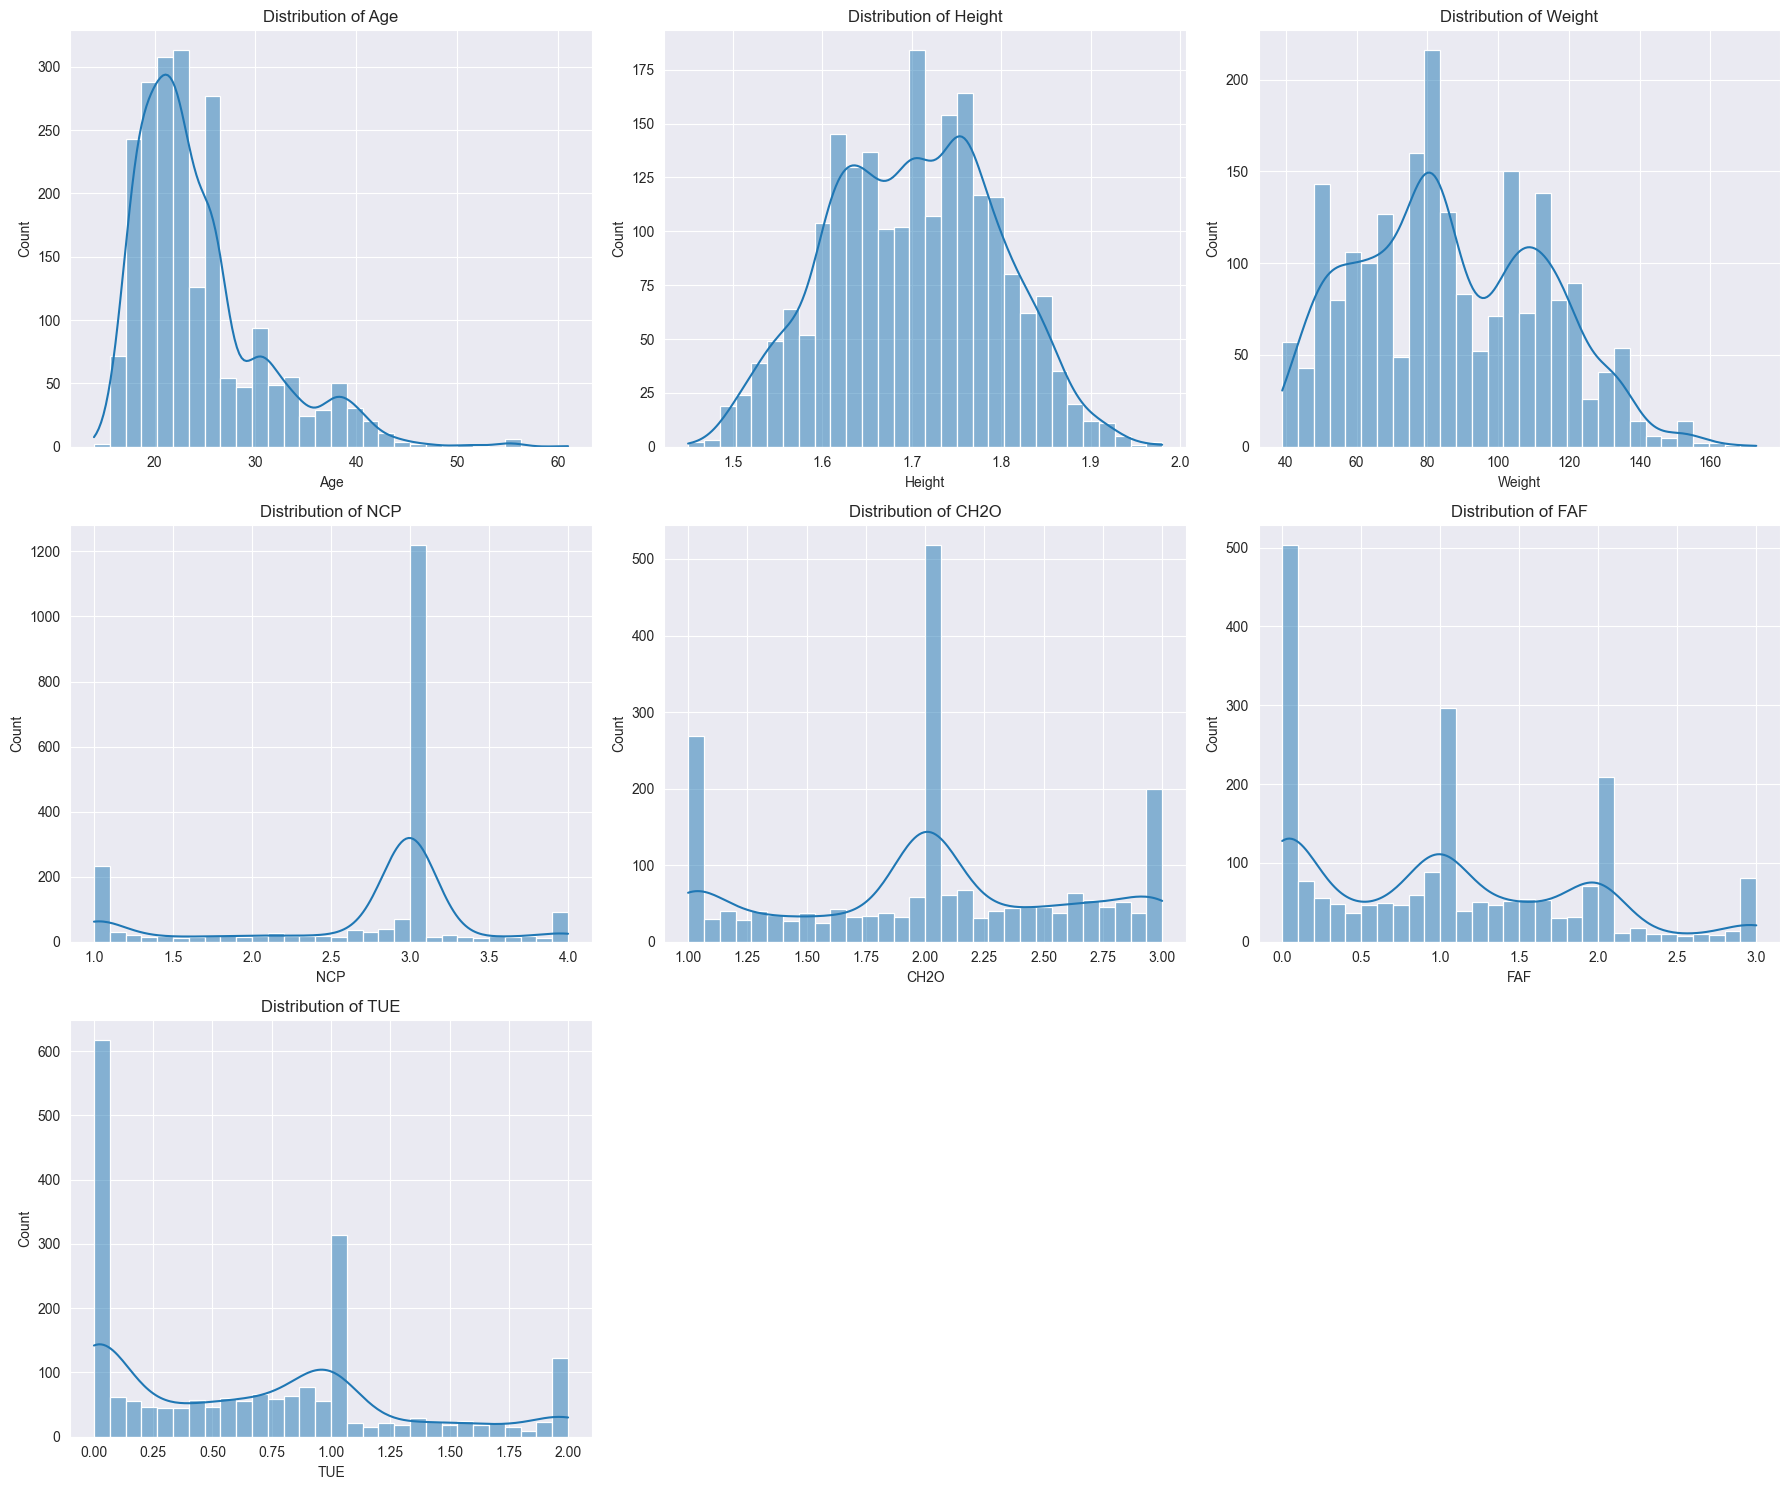

In [30]:
continuous_features = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF', 'TUE']

n_cols = 3
n_rows = (len(continuous_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()  # Flatten in case of multiple rows

for i, col in enumerate(continuous_features):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Remove any empty subplots if total plots < n_rows*n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

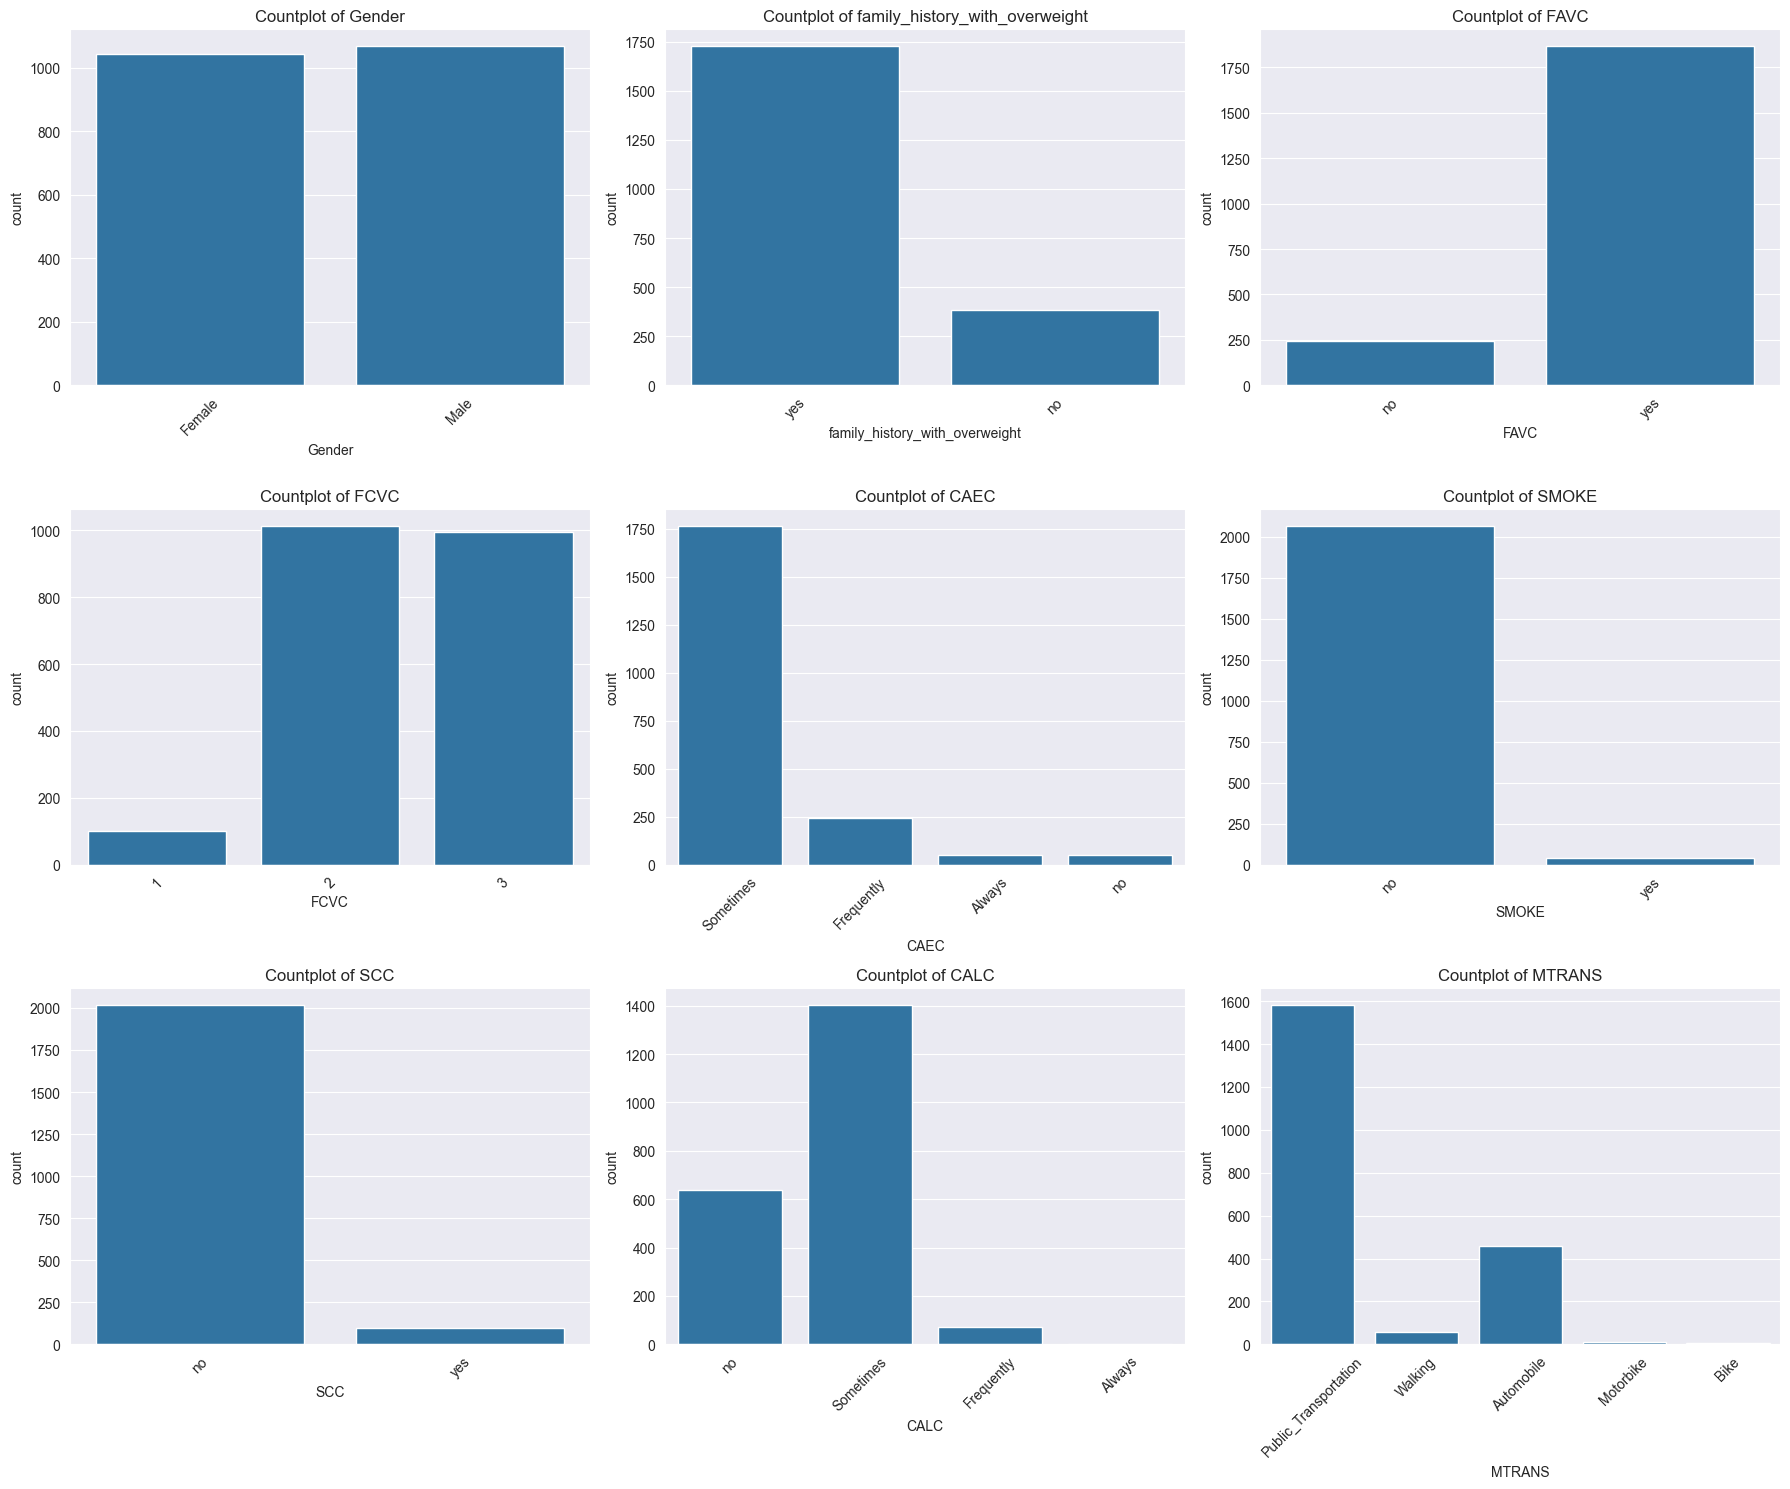

In [31]:
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC',
                        'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()  # Flatten in case of multiple rows

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate x labels for readability if needed

# Remove any empty subplots if total plots < n_rows*n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


## **Correlation Heatmap to Target**

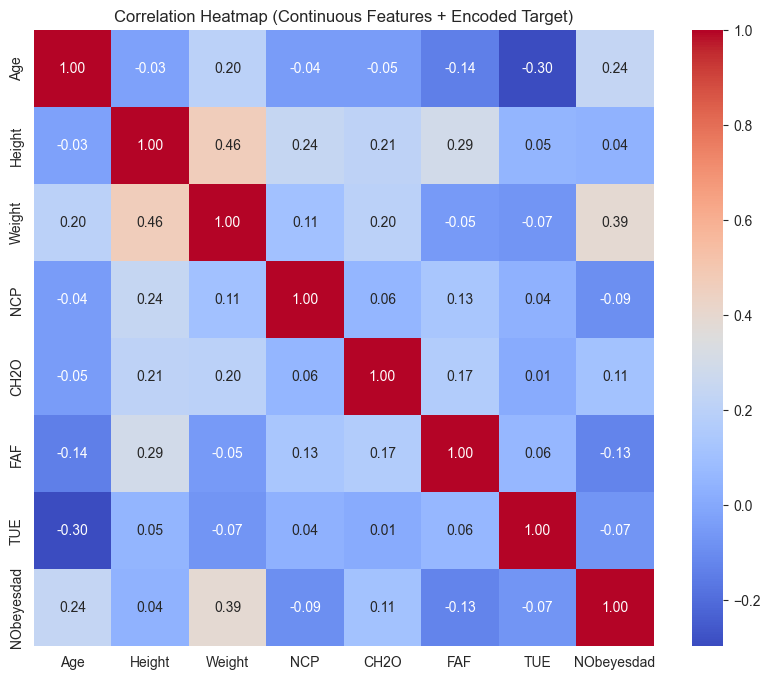

In [38]:
from sklearn.preprocessing import LabelEncoder

continuous_features = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF', 'TUE']

df_encoded = df.copy()
df_encoded['NObeyesdad'] = LabelEncoder().fit_transform(df['NObeyesdad'])

subset = df_encoded[continuous_features + ['NObeyesdad']]

corr = subset.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Continuous Features + Encoded Target)')
plt.show()

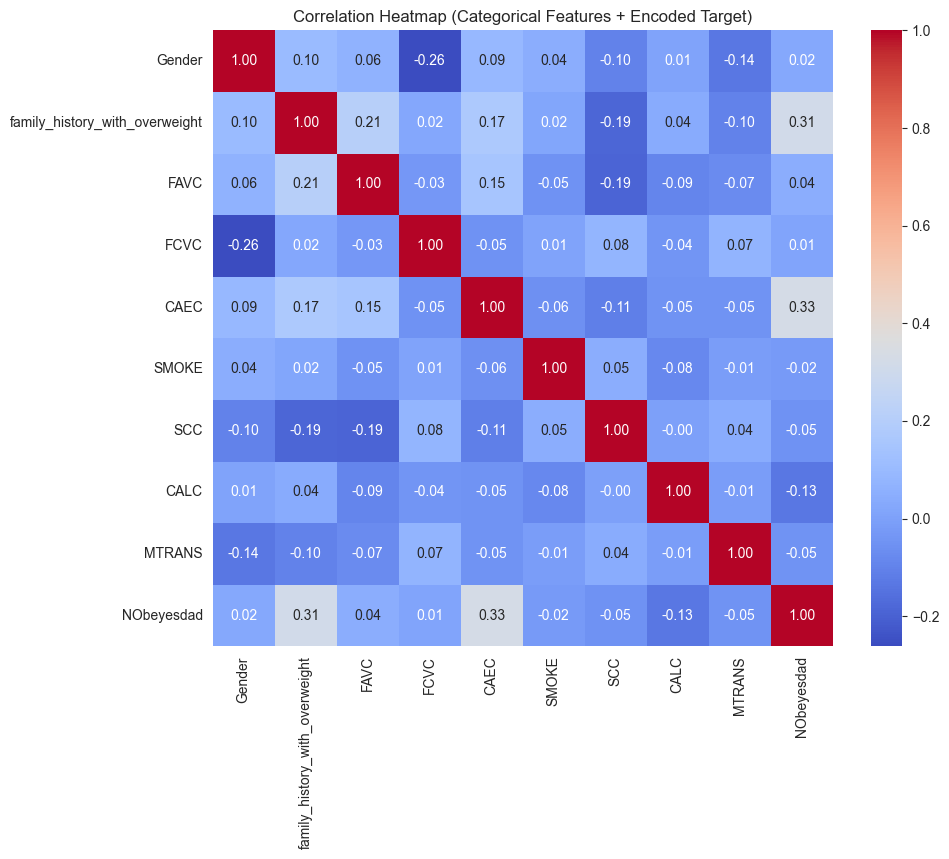

In [48]:
df_encoded = df.copy()

categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC',
                    'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']

for col in categorical_cols:
    df_encoded[col] = LabelEncoder().fit_transform(df[col])
subset = df_encoded[categorical_cols]
corr = subset.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Categorical Features + Encoded Target)')
plt.show()

## **Relationship with Target**

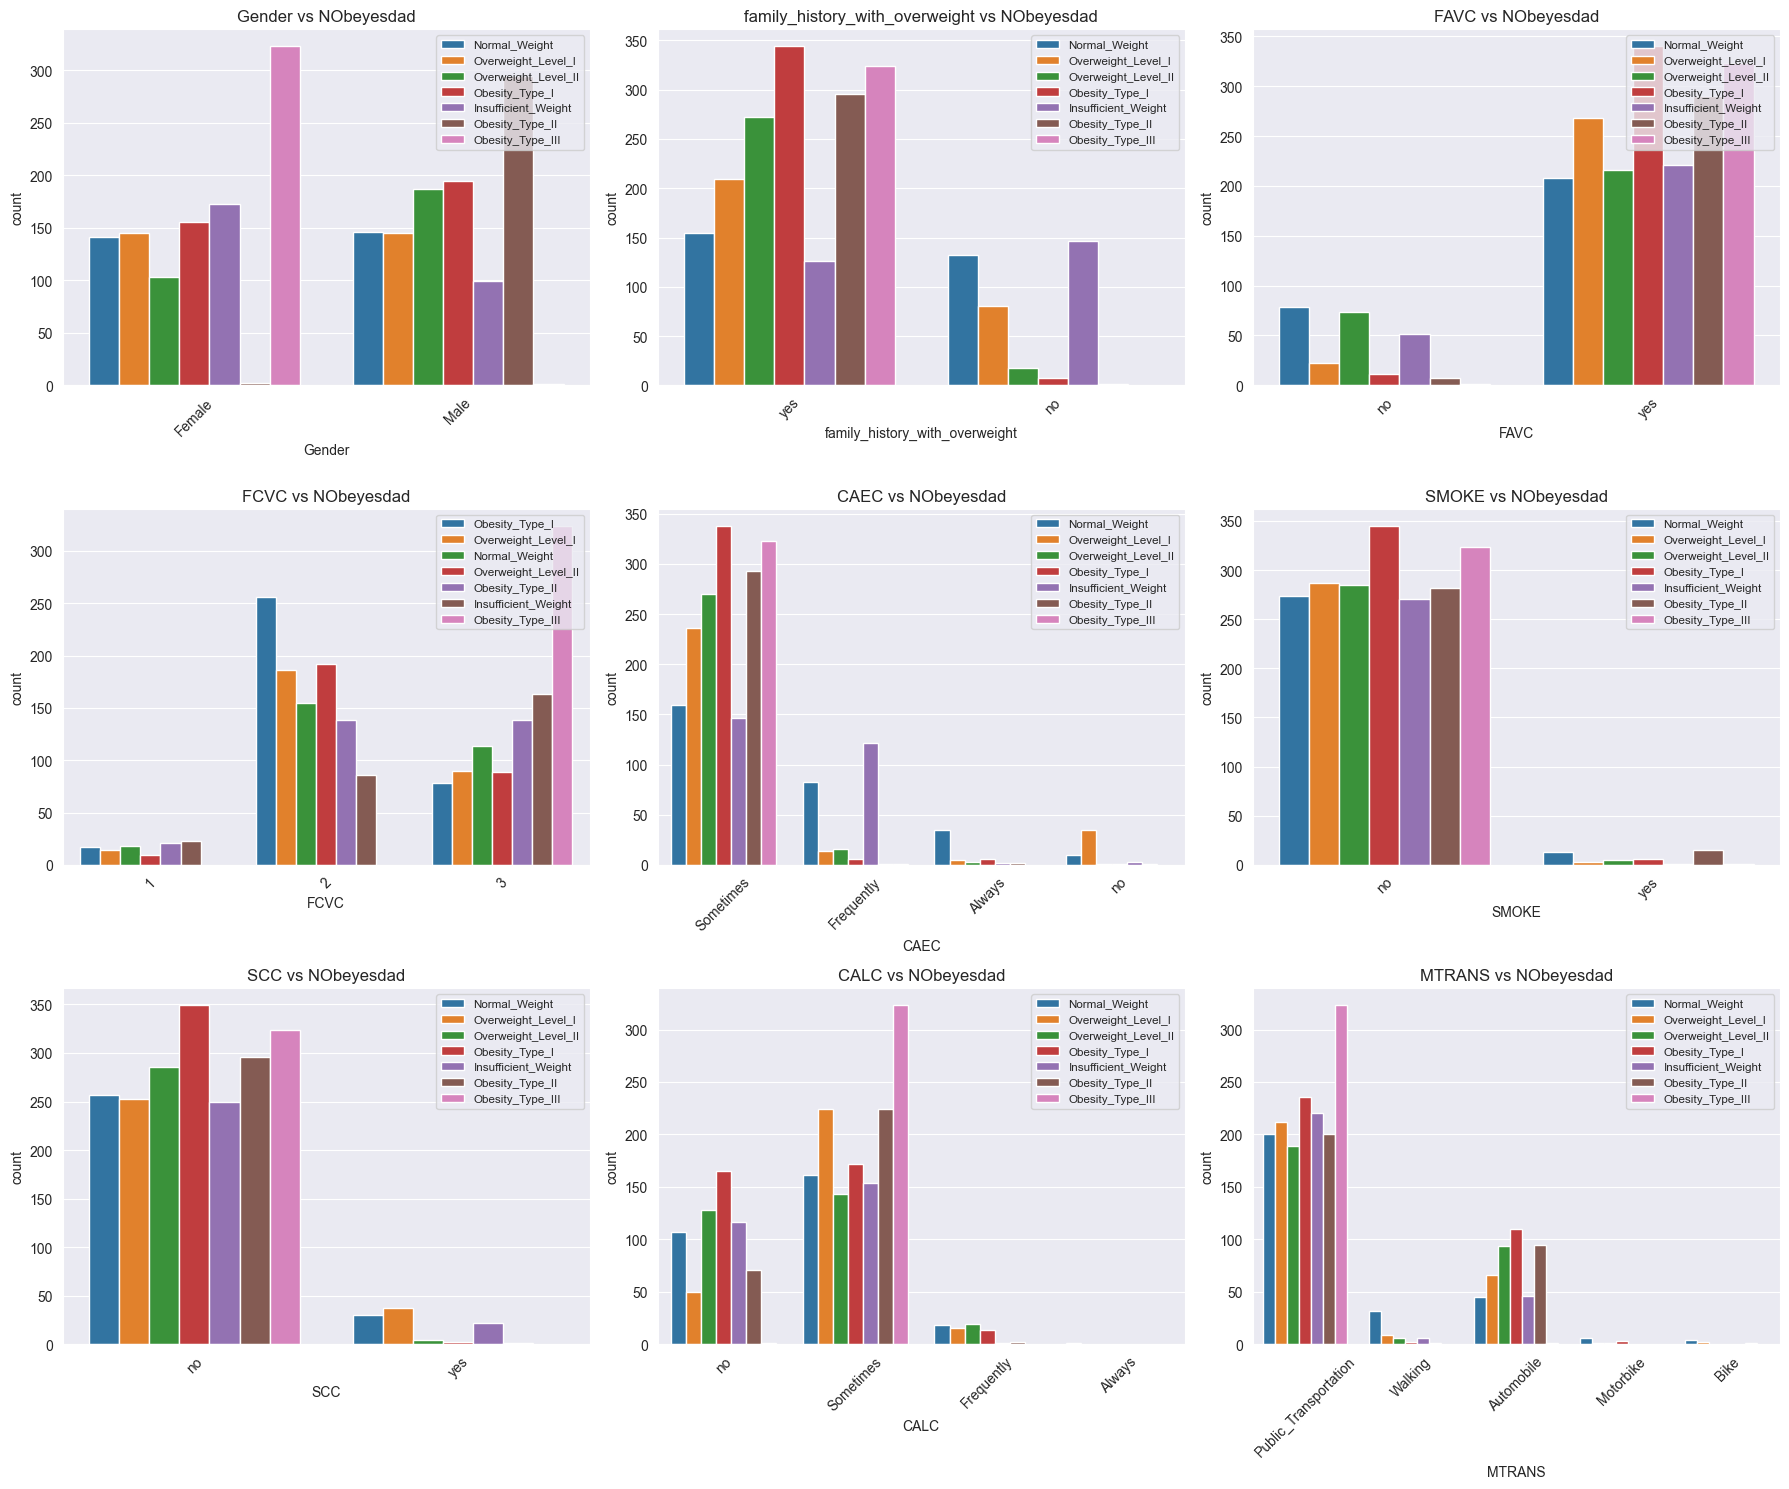

In [33]:
categorical_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC',
                        'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()  # Flatten axes array

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, hue='NObeyesdad', data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs NObeyesdad')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(loc='upper right', fontsize='small')

# Remove any empty subplots if total plots < n_rows*n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

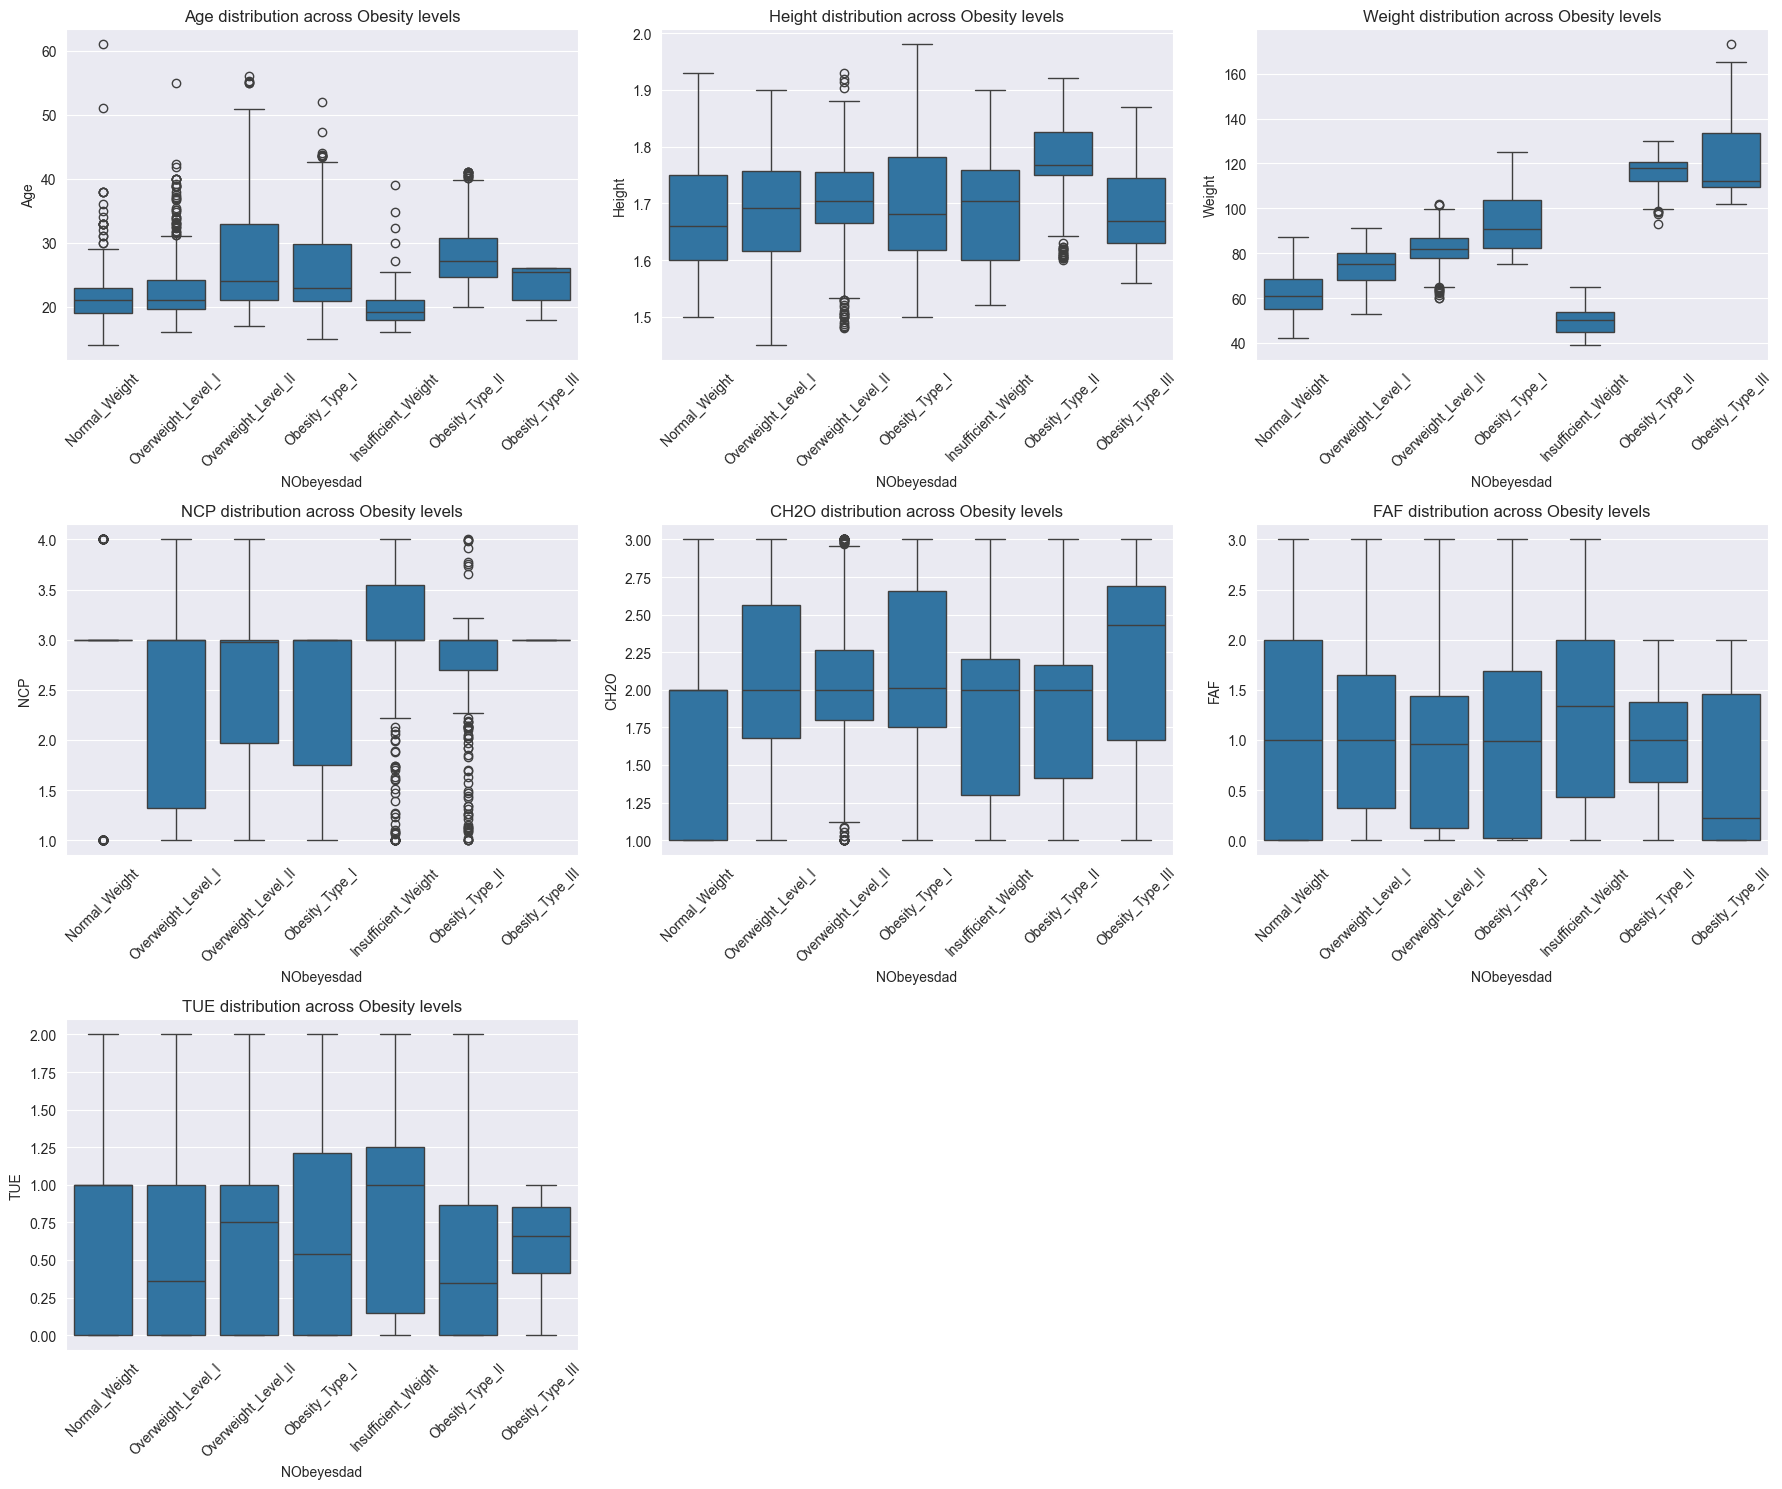

In [34]:
continuous_features = ['Age', 'Height', 'Weight', 'NCP', 'CH2O', 'FAF', 'TUE']

n_cols = 3
n_rows = (len(continuous_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()  # Flatten axes array

for i, col in enumerate(continuous_features):
    sns.boxplot(x='NObeyesdad', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} distribution across Obesity levels')
    axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots if total plots < n_rows*n_cols
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()